Class labels: [0 1 2]
Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


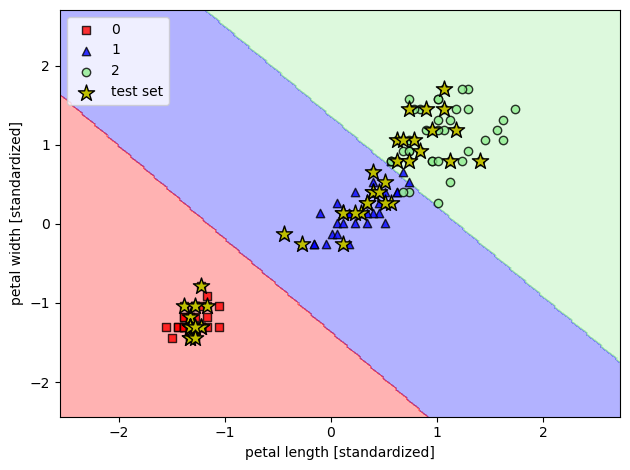

Misclassified samples: 1
Accuracy: 0.98


'\n终端输出结果：\nClass labels: [0 1 2]\nLabels counts in y: [50 50 50]\nLabels counts in y_train: [35 35 35]\nLabels counts in y_test: [15 15 15]\nMisclassified samples: 1\nAccuracy: 0.98\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
 
#? 加载样本数据及其分类标签
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]  #按花瓣划分
#X = iris.data[:,[0,1]]   #按花萼划分
y = iris.target
 
print('Class labels:', np.unique(y))    # 分类标签列表 [0 1 2]
# np.unique(arr): arr为一维数组/列表，结果返回一个列表，去除arr中重复的元素，并从小到大排序
 
 
#? 划分70%训练集和30%测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
"""
train_test_split()函数: 用于将数据集划分为训练集train和测试集test
X: 待划分的样本特征集
y: 数据集X对应的标签
test_size: 0~1表示测试集样本占比、整数表示测试集样本数量
random_state: 随机数种子。在需要重复实验的时候保证得到一组一样的随机数据。每次填1(其他参数一样)，每次得到的随机数组一样；每次填0/不填，每次都不一样
stratify=y: 划分数据集时保证每个类别在训练集和测试集中的比例与原数据集中的比例相同
"""
 
print('Labels counts in y:', np.bincount(y))                # 原数据集中各分类标签出现次数 [50 50 50]
print('Labels counts in y_train:', np.bincount(y_train))    # 训练集中各分类标签出现次数 [35 35 35]
print('Labels counts in y_test:', np.bincount(y_test))      # 测试集中各分类标签出现次数 [15 15 15]  35:15=7:3
# np.bincount(arr): 返回一个数组array，长度=max(arr[i])+1，array[i]=count(arr[i])。（长度=arr中最大元素值+1，每个元素值=它当前索引值在arr中出现的次数）
 
 
#? 标准化训练集和测试集
sc = StandardScaler()   # 定义一个标准缩放器
sc.fit(X_train)         # 计算均值、标准差
X_train_std = sc.transform(X_train) # 使用计算出的均值和标准差进行标准化
X_test_std  = sc.transform(X_test)  # 使用计算出的均值和标准差进行标准化
"""
! StandardScaler()
均值：对每个特征求均值，即对每列求均值
去均值：每个特征的值减去对应特征的均值
标准差：去均值后平方和，然后除以总值的数量，最后开根号
标准分数：去均值、除以标准差
1、中心化：去均值，将整体数据平移，中心为(0,0)
2、缩放：标准分数，进行缩放
标准化：去均值、除以标准差。将数据的分布转为正态分布。每个特征的值 均值=0、方差=1
    目的：
        将特征表现为标准正态分布数据。
        如果某个特征的方差比其他特征大几个数量级，那么它就会在学习算法中占据主导位置，导致学习器不能从其他特征中学习，从而降低精度。
		加快梯度下降求解的速度。
"""
 
 
#? 绘制决策边界图 函数
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    #? 设置标记生成器和颜色图
    markers = ('s', '^', 'o', 'x', 'v')                     # 标记生成器
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')  # 定义颜色图
    cmap = ListedColormap(colors[:len(np.unique(y))])
 
    #? 绘制决策曲面
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1   # x轴范围 x1_min ~ x1_max
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1   # y轴范围 x2_min ~ x2_max
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),   # 生成网络点坐标矩阵
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)                        # 对不同分类进行标记
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap) # 生成边界图
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    #? 绘制 所有样本 散点图
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],    # 散点的x坐标(分类标签==cl)
                    y=X[y == cl, 1],    # 散点的y坐标(分类标签==cl)
                    alpha=0.8,          # 散点的透明度
                    c=colors[idx],      # 散点的颜色
                    marker=markers[idx],# 散点的样式
                    label=cl,           # 散点的图例名称
                    edgecolor='black')  # 散点的边缘颜色
 
    #? 绘制 测试样本 散点图
    if test_idx:    # 默认test_idx=None 如果未设置该参数，则不绘制测试样本
        X_test, y_test = X[test_idx, :], y[test_idx]
 
        plt.scatter(X_test[:, 0],       # 散点的横坐标
                    X_test[:, 1],       # 散点的纵坐标
                    c='y',              # 散点的颜色【黄色】
                    edgecolor='black',  # 散点的边缘颜色【黑色】
                    alpha=1.0,          # 散点的透明度【1】
                    linewidth=1,        # 散点的边缘线宽【1】
                    marker='*',         # 散点的样式【圆圈】
                    s=150,              # 散点的面积【150】
                    label='test set')   # 散点的图例名称【test set】
"""
print(np.arange(x1_min, x1_max, resolution).shape)  # 265
print(np.arange(x2_min, x2_max, resolution).shape)  # 258
print(xx1.shape)    # 258*265   # 258个相同的x值(x1范围)，因为有258个不同y值，说明一个x值对应258个不同y【x坐标竖直复制258份】
print(xx2.shape)    # 258*265   # 265个相同的y值(x2范围)，因为有265个不同x值，说明一个y值对应265个不同x【y坐标水平复制265份】
print(xx1.ravel().shape)    # 68370 =258*265
print(xx2.ravel().shape)    # 68370 =258*265
print(np.array([xx1.ravel(), xx2.ravel()]).shape)   # 2*68370
print(np.array([xx1.ravel(), xx2.ravel()]).T.shape) # 68370*2
Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
print(Z.shape)  # 1*68370
Z = Z.reshape(xx1.shape)
print(Z.shape)  # 258*265   # 预测出网格点的每个分类，reshape成258行预测结果，每行265个具体预测值
x=X[y == 0, 0]  # 分类y=0的x坐标(第二个位置参数=1时为y坐标)
print(X.shape)  # 150*2
print(x.shape)  # 1*50
print(X[range(105, 150), :].shape)  # 45*2
"""
 
 
# Training a svm model using the standardized training data
X_combined_std = np.vstack((X_train_std, X_test_std))   # 竖直堆叠
y_combined = np.hstack((y_train, y_test))               # 水平拼接
"""
np.vstack(tup): tup为一个元组，返回一个竖直堆叠后的数组
np.hstack(tup): tup为一个元组，返回一个水平拼接后的数组
"""
 
 
#? 训练线性支持向量机
svm = SVC(kernel='linear', C=1.0, random_state=1)   # 定义线性支持向量分类器 (linear为线性核函数)
svm.fit(X_train_std, y_train)                       # 根据给定的训练数据拟合训练SVM模型
plot_decision_regions(X_combined_std, y_combined, classifier=svm, test_idx=range(105, 150)) # 绘制决策边界
 
plt.xlabel('petal length [standardized]')   # x轴标签
plt.ylabel('petal width [standardized]')    # y轴标签
plt.legend(loc='upper left')                # 图例位于左上方
plt.tight_layout()                          # 使子图填充整个图像区域
#plt.savefig('images/03_11.png', dpi=300)
plt.show()
 
 
#? 使用测试集进行数据预测
y_pred = svm.predict(X_test_std)    # 用训练好的分类器svm预测数据X_test_std的标签
print('Misclassified samples: %d' % (y_test != y_pred).sum())   # 输出错误分类的样本数
print('Accuracy: %.2f' % svm.score(X_test_std, y_test))         # 输出分类准确率
"""
! (arr1 != arr2).sum():
arr1、arr2为数组类型
(arr1 != arr2): 输出一个列表，元素为bool类型，两数组对应位置不相等为True
.sum(): 统计列表中True的个数
! svm.score(X_test_std, y_test)
返回给定测试集与对应标签的平均准确率
"""
 
 
 
"""
终端输出结果：
Class labels: [0 1 2]
Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]
Misclassified samples: 1
Accuracy: 0.98
"""